# Imports

In [23]:
!pip install pretty_midi

In [24]:
# Central imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import pretty_midi
except ImportError as exc:
    raise ImportError(
        "pretty_midi is required for MIDI analysis. Install with: pip install pretty_midi"
    ) from exc



# Initial Data Analysis
- Dataset path and metadata checks
- Split/year distributions
- Quick composer and duration summaries
- File existence sanity checks

In [25]:
# Set dataset path
DATASET_PATH = "/kaggle/input/datasets/alonhaviv/the-maestro-dataset-v3-0-0/maestro-v3.0.0"

if not os.path.isdir(DATASET_PATH):
    raise FileNotFoundError(
        f"DATASET_PATH does not exist: {DATASET_PATH}. Update this path."
    )

print("Dataset path verified")

Dataset path verified


In [26]:
print("=== TOP LEVEL FILES ===")
top_files = os.listdir(DATASET_PATH)
print(top_files)

=== TOP LEVEL FILES ===
['2017', '2011', '2004', 'LICENSE', 'maestro-v3.0.0.csv', 'README', '2006', 'maestro-v3.0.0.json', '2014', '2013', '2009', '2015', '2008', '2018']


In [27]:
print("=== FIND METADATA FILE ===")

csv_path = None
for f in top_files:
    if f.endswith(".csv"):
        csv_path = os.path.join(DATASET_PATH, f)
        print("Found CSV:", csv_path)
        break

if csv_path is None:
    raise FileNotFoundError("No metadata CSV file found.")

=== FIND METADATA FILE ===
Found CSV: /kaggle/input/datasets/alonhaviv/the-maestro-dataset-v3-0-0/maestro-v3.0.0/maestro-v3.0.0.csv


In [28]:
print("=== LOAD METADATA ===")

df = pd.read_csv(csv_path)

print("Columns:")
print(df.columns)

print("\nFirst 5 rows:")
df.head()

=== LOAD METADATA ===
Columns:
Index(['canonical_composer', 'canonical_title', 'split', 'year',
       'midi_filename', 'audio_filename', 'duration'],
      dtype='object')

First 5 rows:


,canonical_composer,canonical_title,split,year,midi_filename,audio_filename,duration
0,Alban Berg,Sonata Op. 1,train,2018,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,698.661160
1,Alban Berg,Sonata Op. 1,train,2008,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,759.518471
2,Alban Berg,Sonata Op. 1,train,2017,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,464.649433
3,Alexander Scriabin,"24 Preludes Op. 11, No. 13-24",train,2004,2004/MIDI-Unprocessed_XP_21_R1_2004_01_ORIG_MI...,2004/MIDI-Unprocessed_XP_21_R1_2004_01_ORIG_MI...,872.640588
4,Alexander Scriabin,"3 Etudes, Op. 65",validation,2006,2006/MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MI...,2006/MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MI...,397.857508


In [29]:
print("=== BASIC STATS ===")

print("Total samples:", len(df))

print("\nSplit distribution:")
print(df['split'].value_counts())

print("\nYear distribution:")
print(df['year'].value_counts().sort_index())

=== BASIC STATS ===
Total samples: 1276

Split distribution:
split
train         962
test          177
validation    137
Name: count, dtype: int64

Year distribution:
year
2004    132
2006    115
2008    147
2009    125
2011    163
2013    127
2014    105
2015    129
2017    140
2018     93
Name: count, dtype: int64


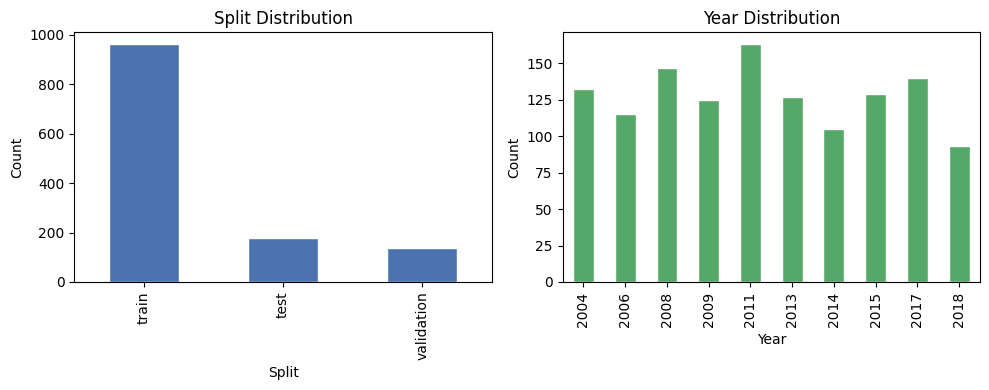

In [30]:
# Visualize split and year distributions
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df["split"].value_counts().plot(kind="bar", color="#4C72B0", edgecolor="white")
plt.title("Split Distribution")
plt.xlabel("Split")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
df["year"].value_counts().sort_index().plot(kind="bar", color="#55A868", edgecolor="white")
plt.title("Year Distribution")
plt.xlabel("Year")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [31]:
print("=== MUSICAL INSIGHTS ===")

print("\nTop composers:")
print(df['canonical_composer'].value_counts().head(10))

print("\nDuration stats (seconds):")
print(df['duration'].describe())

=== MUSICAL INSIGHTS ===

Top composers:
canonical_composer
Frédéric Chopin            201
Franz Schubert             186
Ludwig van Beethoven       146
Johann Sebastian Bach      145
Franz Liszt                131
Sergei Rachmaninoff         59
Robert Schumann             49
Claude Debussy              45
Joseph Haydn                40
Wolfgang Amadeus Mozart     38
Name: count, dtype: int64

Duration stats (seconds):
count    1276.000000
mean      560.463595
std       443.057431
min        45.155208
25%       261.981576
50%       429.168241
75%       685.018817
max      2624.663508
Name: duration, dtype: float64


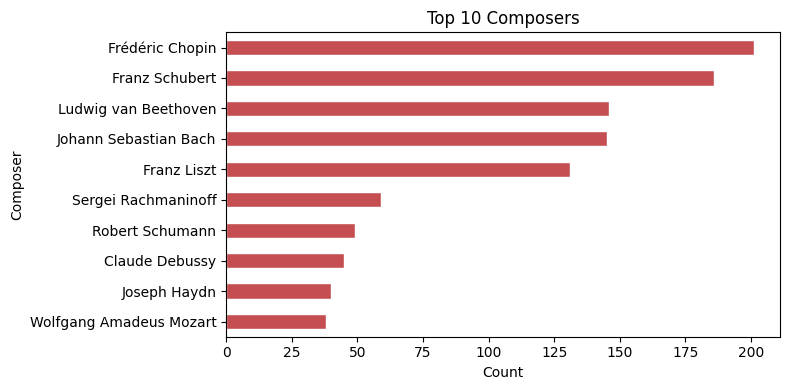

<Figure size 600x400 with 0 Axes>

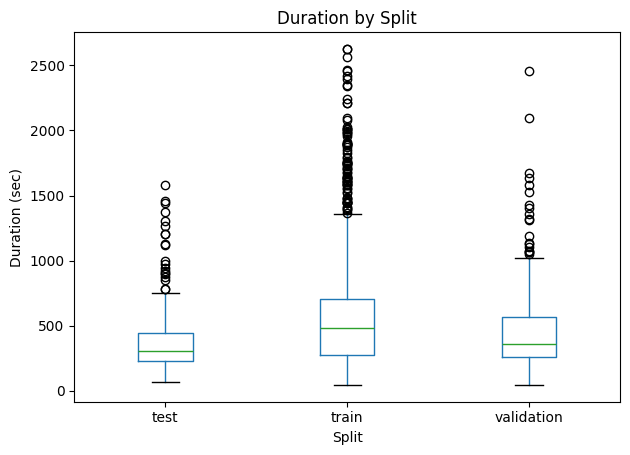

,count,mean,median,min,max
split,,,,,
test,177.0,406.372436,306.104269,65.948118,1579.194468
train,962.0,595.922497,485.909760,45.169560,2624.663508
validation,137.0,510.556082,359.457440,45.155208,2457.807371


In [32]:
# Top composers (bar chart)
top_composers = df["canonical_composer"].value_counts().head(10)
plt.figure(figsize=(8, 4))
top_composers.sort_values().plot(kind="barh", color="#C44E52", edgecolor="white")
plt.title("Top 10 Composers")
plt.xlabel("Count")
plt.ylabel("Composer")
plt.tight_layout()
plt.show()

# Duration summary by split (boxplot + compact table)
plt.figure(figsize=(6, 4))
df.boxplot(column="duration", by="split", grid=False)
plt.title("Duration by Split")
plt.suptitle("")
plt.xlabel("Split")
plt.ylabel("Duration (sec)")
plt.tight_layout()
plt.show()

duration_summary = (
    df.groupby("split")["duration"]
    .describe()[["count", "mean", "50%", "min", "max"]]
    .rename(columns={"50%": "median"})
)
duration_summary

In [33]:
print("=== CHECK MIDI FILES ===")

sample_paths = df['midi_filename'].head(5).tolist()

for p in sample_paths:
    full_path = os.path.join(DATASET_PATH, p)
    print(full_path, "-> Exists:", os.path.exists(full_path))

=== CHECK MIDI FILES ===
/kaggle/input/datasets/alonhaviv/the-maestro-dataset-v3-0-0/maestro-v3.0.0/2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.midi -> Exists: True
/kaggle/input/datasets/alonhaviv/the-maestro-dataset-v3-0-0/maestro-v3.0.0/2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MID--AUDIO_03_R2_2008_wav--2.midi -> Exists: True
/kaggle/input/datasets/alonhaviv/the-maestro-dataset-v3-0-0/maestro-v3.0.0/2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-split_07-07-17_Piano-e_3-02_wav--3.midi -> Exists: True
/kaggle/input/datasets/alonhaviv/the-maestro-dataset-v3-0-0/maestro-v3.0.0/2004/MIDI-Unprocessed_XP_21_R1_2004_01_ORIG_MID--AUDIO_21_R1_2004_01_Track01_wav.midi -> Exists: True
/kaggle/input/datasets/alonhaviv/the-maestro-dataset-v3-0-0/maestro-v3.0.0/2006/MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MID--AUDIO_17_R1_2006_04_Track04_wav.midi -> Exists: True


In [34]:
print("Counting valid MIDI files...")

valid_count = 0
for p in df['midi_filename']:
    if os.path.exists(os.path.join(DATASET_PATH, p)):
        valid_count += 1

print("Valid MIDI files:", valid_count)

Counting valid MIDI files...
Valid MIDI files: 1276


In [35]:
print("=== LONG vs SHORT FILES ===")

print("Files < 60 sec:", len(df[df['duration'] < 60]))
print("Files 60–300 sec:", len(df[(df['duration'] >= 60) & (df['duration'] <= 300)]))
print("Files > 300 sec:", len(df[df['duration'] > 300]))

=== LONG vs SHORT FILES ===
Files < 60 sec: 3
Files 60–300 sec: 408
Files > 300 sec: 865


# Step 2: Exploratory Data Analysis
- Duration histogram
- Note count per piece
- Pitch distribution
- Velocity distribution
- Sparsity check (piano-roll)

In [36]:
# EDA helpers
sample_size = len(df)
sample_df = df.sample(n=sample_size, random_state=42)
sample_paths = sample_df["midi_filename"].dropna().tolist()

valid_paths = []
for rel_path in sample_paths:
    full_path = os.path.join(DATASET_PATH, rel_path)
    if os.path.exists(full_path):
        valid_paths.append(full_path)

print("Sample size:", sample_size)
print("Valid MIDI paths:", len(valid_paths))

Sample size: 1276
Valid MIDI paths: 1276


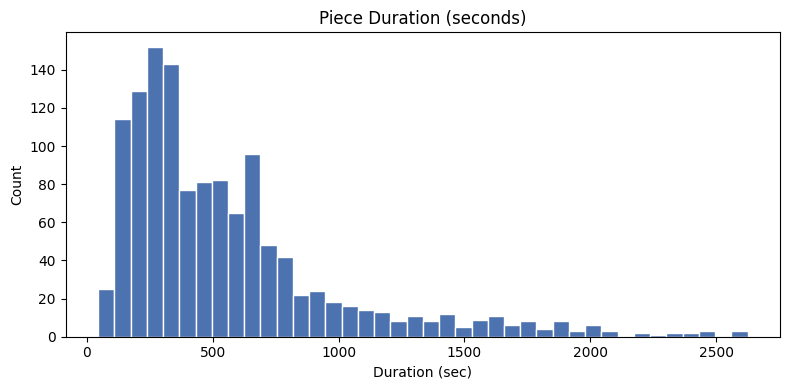

In [37]:
# Duration histogram
plt.figure(figsize=(8, 4))
plt.hist(df["duration"], bins=40, color="#4C72B0", edgecolor="white")
plt.title("Piece Duration (seconds)")
plt.xlabel("Duration (sec)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [38]:
# Compute note-level stats from the sample
note_counts = []
pitch_counts = np.zeros(88, dtype=int)
velocities = []

for midi_path in valid_paths:
    try:
        midi = pretty_midi.PrettyMIDI(midi_path)
    except Exception as exc:
        print("Skip unreadable:", midi_path, "->", exc)
        continue

    notes = []
    for inst in midi.instruments:
        notes.extend(inst.notes)

    note_counts.append(len(notes))
    for n in notes:
        if 21 <= n.pitch <= 108:
            pitch_counts[n.pitch - 21] += 1
            velocities.append(n.velocity)

print("Files analyzed:", len(note_counts))

Files analyzed: 1276


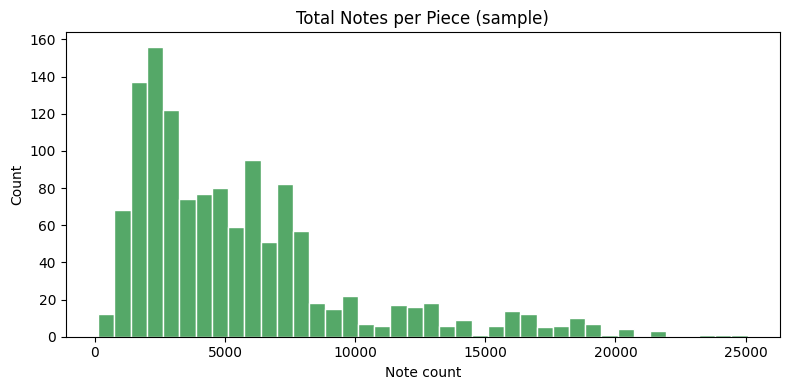

In [39]:
# Note count distribution
plt.figure(figsize=(8, 4))
plt.hist(note_counts, bins=40, color="#55A868", edgecolor="white")
plt.title("Total Notes per Piece (sample)")
plt.xlabel("Note count")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

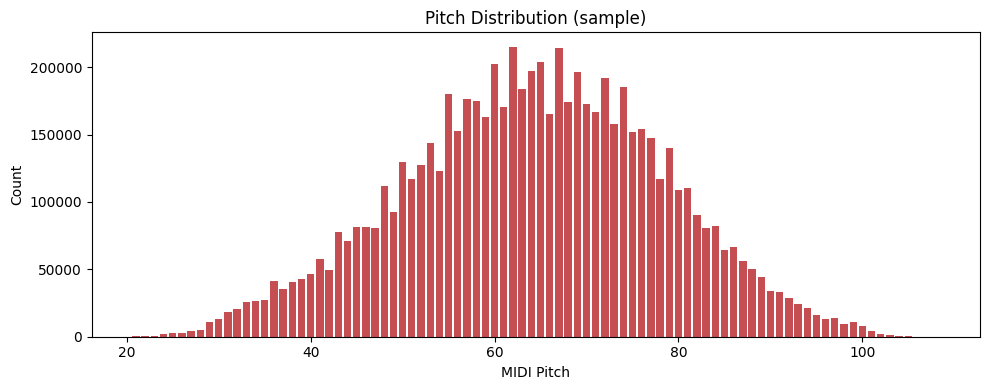

In [40]:
# Pitch distribution across 88 keys
plt.figure(figsize=(10, 4))
plt.bar(range(21, 109), pitch_counts, color="#C44E52")
plt.title("Pitch Distribution (sample)")
plt.xlabel("MIDI Pitch")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

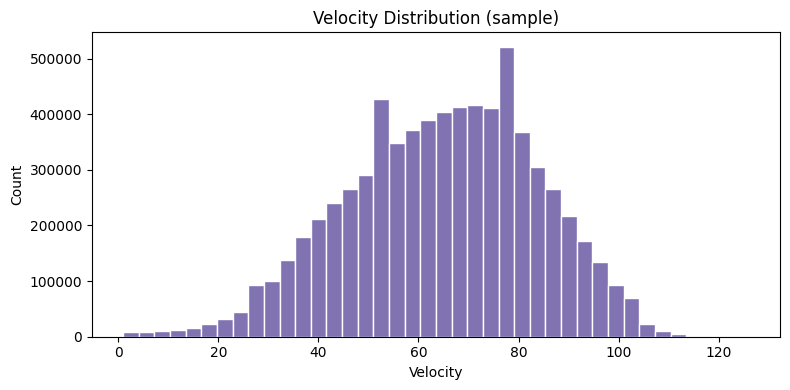

In [41]:
# Velocity distribution
plt.figure(figsize=(8, 4))
plt.hist(velocities, bins=40, color="#8172B2", edgecolor="white")
plt.title("Velocity Distribution (sample)")
plt.xlabel("Velocity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [42]:
# Sparsity check using piano-roll on a few files
fs = 16
check_paths = valid_paths[:2]
for midi_path in check_paths:
    try:
        midi = pretty_midi.PrettyMIDI(midi_path)
    except Exception as exc:
        print("Skip unreadable:", midi_path, "->", exc)
        continue

    roll = midi.get_piano_roll(fs=fs)
    roll = roll[21:109, :].T
    if roll.size == 0:
        print("Empty roll:", midi_path)
        continue

    nonzero = np.count_nonzero(roll)
    sparsity = 1.0 - (nonzero / roll.size)
    print(os.path.basename(midi_path))
    print("  Shape:", roll.shape, "Nonzero fraction:", nonzero / roll.size, "Sparsity:", sparsity)

MIDI-Unprocessed_14_R1_2009_01-05_ORIG_MID--AUDIO_14_R1_2009_14_R1_2009_03_WAV.midi
  Shape: (2123, 88) Nonzero fraction: 0.01110671005866484 Sparsity: 0.9888932899413352
MIDI-Unprocessed_11_R1_2009_01-05_ORIG_MID--AUDIO_11_R1_2009_11_R1_2009_03_WAV.midi
  Shape: (1455, 88) Nonzero fraction: 0.04167447672602312 Sparsity: 0.9583255232739769
